In [108]:
#import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.linear_model import  Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error 
import torch
import torch.nn as nn
import os
import time
import warnings
warnings.filterwarnings('ignore')

In [2]:
#ensure reproducible results
torch.manual_seed(42)
np.random.seed(42)

In [3]:
#import the dataset with the peak bloom days time-series
df_kyoto_bloom = pd.read_csv("data/kyoto_data/date-of-the-peak-cherry-tree-blossom-in-kyoto.csv")
df_kyoto_bloom = df_kyoto_bloom[(df_kyoto_bloom["Year"] > 1880) & (df_kyoto_bloom["Year"] < 2026)].copy()
#get the date from the day of the year
df_kyoto_bloom['date'] = pd.to_datetime(df_kyoto_bloom['Year'].astype(str) + 
                                   df_kyoto_bloom['Day of the year with peak cherry blossom'].astype(str).str.zfill(3), 
                                   format='%Y%j')
df_kyoto_bloom

,Entity,Code,Year,Twenty-year average day of the year with peak cherry blossom,Day of the year with peak cherry blossom,date
692,Japan,JPN,1881,105.30,112,1881-04-22
693,Japan,JPN,1882,105.15,97,1882-04-07
694,Japan,JPN,1883,104.65,107,1883-04-17
695,Japan,JPN,1884,104.20,109,1884-04-18
696,Japan,JPN,1885,104.60,113,1885-04-23
...,...,...,...,...,...,...
828,Japan,JPN,2021,94.75,85,2021-03-26
829,Japan,JPN,2022,94.75,91,2022-04-01
830,Japan,JPN,2023,94.05,84,2023-03-25
831,Japan,JPN,2024,94.20,95,2024-04-04


In [4]:
df_kyoto_bloom.dtypes

Entity                                                                  object
Code                                                                    object
Year                                                                     int64
Twenty-year average day of the year with peak cherry blossom           float64
Day of the year with peak cherry blossom                                 int64
date                                                            datetime64[ns]
dtype: object

In [5]:
df_kyoto_bloom.describe()

,Year,Twenty-year average day of the year with peak cherry blossom,Day of the year with peak cherry blossom,date
count,141.000000,141.000000,141.000000,141
mean,1953.936170,101.275887,100.460993,1954-03-18 03:44:40.851063808
min,1881.000000,93.950000,84.000000,1881-04-22 00:00:00
25%,1917.000000,98.600000,97.000000,1917-04-13 00:00:00
50%,1955.000000,101.650000,99.000000,1955-04-07 00:00:00
75%,1990.000000,104.250000,105.000000,1990-03-29 00:00:00
max,2025.000000,106.500000,115.000000,2025-04-04 00:00:00
std,42.114506,3.419391,5.800884,NaN


In [6]:
#check the year when sakura started to bloom earlier than in other years
df_kyoto_bloom.loc[df_kyoto_bloom["Day of the year with peak cherry blossom"] == 84]

,Entity,Code,Year,Twenty-year average day of the year with peak cherry blossom,Day of the year with peak cherry blossom,date
830,Japan,JPN,2023,94.05,84,2023-03-25


In [7]:
#check the year when sakura started to bloom later than in other years
df_kyoto_bloom.loc[df_kyoto_bloom["Day of the year with peak cherry blossom"] == 115]

,Entity,Code,Year,Twenty-year average day of the year with peak cherry blossom,Day of the year with peak cherry blossom,date
703,Japan,JPN,1892,106.25,115,1892-04-24


In [8]:
#create separation based on blooming season, rename the dataframe columns
df_kyoto_bloom["season"] = df_kyoto_bloom["date"].dt.year
df_kyoto_bloom = df_kyoto_bloom.rename({"Year" : "year", "Twenty-year average day of the year with peak cherry blossom" : "20-year avg day of the year with peak cherry blossom","Day of the year with peak cherry blossom" : "bloom day of the year"}, axis=1)
df_kyoto_bloom = df_kyoto_bloom[["date", "season", "20-year avg day of the year with peak cherry blossom", "bloom day of the year"]]

In [9]:
df_kyoto_bloom

,date,season,20-year avg day of the year with peak cherry blossom,bloom day of the year
692,1881-04-22,1881,105.30,112
693,1882-04-07,1882,105.15,97
694,1883-04-17,1883,104.65,107
695,1884-04-18,1884,104.20,109
696,1885-04-23,1885,104.60,113
...,...,...,...,...
828,2021-03-26,2021,94.75,85
829,2022-04-01,2022,94.75,91
830,2023-03-25,2023,94.05,84
831,2024-04-04,2024,94.20,95


In [10]:
#function for weather dataset preprocessing
def kyoto_weather_preprocessing(df_path):
    df = pd.read_csv(df_path, encoding="shift-jis", skiprows=7, header=None) #read the dataframe correctly
    col_ind = [0, 1, 4, 7] #get only needed columns
    df = df.iloc[:, col_ind].copy()
    df.columns = ["date", "max temp", "min temp", "avg temp"] #name the extracted columns
    df["date"] = pd.to_datetime(df["date"]) #allign a datetime datatype to the "date" coumn
    numeric_cols = ["max temp", "min temp", "avg temp"]
    #allign the float datatype to the numeric columns
    for col in numeric_cols:
        df[col] = df[col].astype(float)
    df = df[["date", "min temp", "max temp", "avg temp"]]
    return df

In [11]:
#preprocess each weather dataframe and concat them into a single dataset
df_kyoto_weather_1 = kyoto_weather_preprocessing("data/kyoto_data/data.csv")
df_kyoto_weather_2 = kyoto_weather_preprocessing("data/kyoto_data/data (1).csv")
df_kyoto_weather_3 = kyoto_weather_preprocessing("data/kyoto_data/data (2).csv")
df_kyoto_weather_4 = kyoto_weather_preprocessing("data/kyoto_data/data (3).csv")
df_kyoto_weather_5 = kyoto_weather_preprocessing("data/kyoto_data/data (4).csv")
df_kyoto_weather_6 = kyoto_weather_preprocessing("data/kyoto_data/data (5).csv")
df_kyoto_weather_7 = kyoto_weather_preprocessing("data/kyoto_data/data (6).csv")
df_kyoto_weather_8 = kyoto_weather_preprocessing("data/kyoto_data/data (7).csv")
df_kyoto_weather_9 = kyoto_weather_preprocessing("data/kyoto_data/data (8).csv")
df_kyoto_weather_10 = kyoto_weather_preprocessing("data/kyoto_data/data (9).csv")
df_kyoto_weather_11 = kyoto_weather_preprocessing("data/kyoto_data/data (10).csv")
df_kyoto_weather_12 = kyoto_weather_preprocessing("data/kyoto_data/data (11).csv")
df_kyoto_weather_13 = kyoto_weather_preprocessing("data/kyoto_data/data (12).csv")
df_kyoto_weather_14 = kyoto_weather_preprocessing("data/kyoto_data/data (13).csv")
df_kyoto_weather_15 = kyoto_weather_preprocessing("data/kyoto_data/data (14).csv")

df_kyoto_weather = pd.concat([df_kyoto_weather_1, df_kyoto_weather_2, df_kyoto_weather_3, df_kyoto_weather_4, df_kyoto_weather_5, df_kyoto_weather_6,
                              df_kyoto_weather_7, df_kyoto_weather_8, df_kyoto_weather_9, df_kyoto_weather_10, df_kyoto_weather_11, 
                              df_kyoto_weather_12, df_kyoto_weather_13, df_kyoto_weather_14, df_kyoto_weather_15])

In [12]:
df_kyoto_weather

,date,min temp,max temp,avg temp
0,1880-11-01,4.4,17.2,9.1
1,1880-11-02,2.0,18.3,8.6
2,1880-11-03,4.4,22.4,12.9
3,1880-11-04,6.9,21.8,13.7
4,1880-11-05,6.4,20.8,12.7
...,...,...,...,...
1942,2025-04-26,8.0,23.3,15.2
1943,2025-04-27,9.1,26.1,18.0
1944,2025-04-28,11.7,21.9,16.3
1945,2025-04-29,9.7,18.8,13.9


In [13]:
#and now we have 52776 days for the dataset with 1881-2025 year-span and "date", "min temp", "max temp", "avg temp" columns with correctly alligned 
#datatypes

In [14]:
#check that the datetypes are correct once again
df_kyoto_weather.dtypes

date        datetime64[ns]
min temp           float64
max temp           float64
avg temp           float64
dtype: object

In [15]:
df_kyoto_weather.describe()

,date,min temp,max temp,avg temp
count,52776,52770.000000,52770.000000,52770.000000
mean,1953-01-30 12:00:00,10.230919,20.485007,14.900404
min,1880-11-01 00:00:00,-11.900000,-0.200000,-3.700000
25%,1916-12-16 18:00:00,2.000000,12.500000,6.900000
50%,1953-01-30 12:00:00,9.800000,21.000000,15.100000
75%,1989-03-16 06:00:00,18.400000,27.900000,22.500000
max,2025-04-30 00:00:00,29.200000,39.800000,32.800000
std,NaN,9.050617,8.901380,8.743166


In [16]:
#create separation based on blooming season as well
df_kyoto_weather["season"] = df_kyoto_weather["date"].dt.year
df_kyoto_weather.loc[df_kyoto_weather["date"].dt.month >= 11, "season"] += 1

In [17]:
#create seasonal window from November to April, get rid of Febraury 29 for leap years
df_kyoto_weather = df_kyoto_weather[(df_kyoto_weather["date"].dt.month >= 11) | (df_kyoto_weather["date"].dt.month <= 4)].copy()
df_kyoto_weather = df_kyoto_weather[~((df_kyoto_weather["date"].dt.month == 2) & (df_kyoto_weather["date"].dt.day == 29))]

In [18]:
#ensure the absense of February 29
df_kyoto_weather.loc[(df_kyoto_weather["date"].dt.month == 2) & (df_kyoto_weather["date"].dt.day == 29)]

,date,min temp,max temp,avg temp,season


In [19]:
df_kyoto_weather = df_kyoto_weather.sort_values(["season", "date"])

In [20]:
# create addittional meteorological features to simplify the neural network training process
df_kyoto_weather["cumulative avg temp"] = (df_kyoto_weather.groupby("season")["avg temp"].cumsum())
df_kyoto_weather["daily gdd"] = (df_kyoto_weather["avg temp"] - 5).clip(lower=0)
df_kyoto_weather["cumulative gdd"] = (df_kyoto_weather.groupby("season")["daily gdd"].cumsum())
df_kyoto_weather["chill"] = ((7 - df_kyoto_weather["avg temp"]).clip(lower=0))
df_kyoto_weather["cumulative chill"] = (df_kyoto_weather.groupby("season")["chill"].cumsum())
df_kyoto_weather["7-day rolling avg temp"] = (df_kyoto_weather.groupby("season")["avg temp"].transform(lambda x: x.rolling(7, min_periods=1).mean()))
df_kyoto_weather["day in season"] = (df_kyoto_weather.groupby("season").cumcount())

In [21]:
#set the chill units threshold for cherry blossom's(Prunus × yedoensis) endodormancy release. 
#this threshold marks the transition from endodormancy (a chilling-dependent phase (November-January) during which buds cannot grow regardless of 
#temperature, requiring approximately 800 chill units (61 days below 10.1°C) for completion) to ecodormancy (the subsequent 
#forcing-dependent phase (February-April) where development proceeds based on heat accumulation above 5°C, requiring approximately 400 GDD to reach 
#peak bloom).

chill_threshold = 800
#create phenological growth phases related features 
df_kyoto_weather["chill met"] = df_kyoto_weather["cumulative chill"] >= chill_threshold
df_kyoto_weather["chill completion doy"] = (df_kyoto_weather[df_kyoto_weather["chill met"]].groupby("season")["date"].transform("min"))
df_kyoto_weather["chill completion doy"] = (
    df_kyoto_weather["chill completion doy"].dt.dayofyear)
chill_day = (df_kyoto_weather.groupby("season")["chill completion doy"].max())
df_kyoto_weather["gdd after chill"] = np.where(df_kyoto_weather["cumulative chill"] >= chill_threshold, df_kyoto_weather["daily gdd"],0)
df_kyoto_weather["cumulative gdd after chill"] = (df_kyoto_weather.groupby("season")["gdd after chill"].cumsum())
forcing_total = (
    df_kyoto_weather.groupby("season")["cumulative gdd after chill"].max())
df_kyoto_weather = df_kyoto_weather.merge(df_kyoto_bloom[["season", "bloom day of the year", "20-year avg day of the year with peak cherry blossom"]],
              on="season", how="left")

df_kyoto_weather["days after chill"] = (df_kyoto_weather["bloom day of the year"] - df_kyoto_weather["chill completion doy"])
days_after_chill = (df_kyoto_weather.groupby("season")["days after chill"].max())
climatology = (df_kyoto_weather.groupby(df_kyoto_weather["date"].dt.dayofyear)["avg temp"].mean())

#build additional climatological features that also detect temperature anomalies.
df_kyoto_weather["clim avg"] = df_kyoto_weather["date"].dt.dayofyear.map(climatology)

df_kyoto_weather["temp anomaly"] = df_kyoto_weather["avg temp"] - df_kyoto_weather["clim avg"]

df_kyoto_weather["cumulative temp anomaly"] = (
    df_kyoto_weather.groupby("season")["temp anomaly"].cumsum())
df_kyoto_weather["gdd diff"] = (df_kyoto_weather.groupby("season")["cumulative gdd"].diff())

df_kyoto_weather["gdd acceleration"] = (df_kyoto_weather.groupby("season")["gdd diff"].diff())

In [22]:
#get only necessary columns.
df_kyoto_weather = df_kyoto_weather[["date", "season", "min temp", 
                                     "max temp", "avg temp", "cumulative avg temp", "7-day rolling avg temp", "daily gdd", 
                                     "cumulative gdd", "chill", "cumulative chill", "gdd after chill", "cumulative gdd after chill", 
                                     "clim avg", "temp anomaly", "cumulative temp anomaly",	"gdd diff",	"gdd acceleration", "day in season", 
                                     "20-year avg day of the year with peak cherry blossom", "bloom day of the year"]]
df_kyoto_weather = df_kyoto_weather.fillna(0)

In [23]:
df_kyoto_weather

,date,season,min temp,max temp,avg temp,cumulative avg temp,7-day rolling avg temp,daily gdd,cumulative gdd,chill,...,gdd after chill,cumulative gdd after chill,clim avg,temp anomaly,cumulative temp anomaly,gdd diff,gdd acceleration,day in season,20-year avg day of the year with peak cherry blossom,bloom day of the year
0,1880-11-01,1881,4.4,17.2,9.1,9.1,9.100000,4.1,4.1,0.0,...,0.0,0.0,13.486207,-4.386207,-4.386207,0.0,0.0,0,105.30,112.0
1,1880-11-02,1881,2.0,18.3,8.6,17.7,8.850000,3.6,7.7,0.0,...,0.0,0.0,13.292414,-4.692414,-9.078621,3.6,0.0,1,105.30,112.0
2,1880-11-03,1881,4.4,22.4,12.9,30.6,10.200000,7.9,15.6,0.0,...,0.0,0.0,13.335862,-0.435862,-9.514483,7.9,4.3,2,105.30,112.0
3,1880-11-04,1881,6.9,21.8,13.7,44.3,11.075000,8.7,24.3,0.0,...,0.0,0.0,13.422759,0.277241,-9.237241,8.7,0.8,3,105.30,112.0
4,1880-11-05,1881,6.4,20.8,12.7,57.0,11.400000,7.7,32.0,0.0,...,0.0,0.0,13.406207,-0.706207,-9.943448,7.7,-1.0,4,105.30,112.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26240,2025-04-26,2025,8.0,23.3,15.2,1640.3,18.000000,10.2,817.4,0.0,...,0.0,0.0,15.060690,0.139310,352.810855,10.2,-0.4,176,93.95,94.0
26241,2025-04-27,2025,9.1,26.1,18.0,1658.3,17.614286,13.0,830.4,0.0,...,0.0,0.0,15.311034,2.688966,355.499821,13.0,2.8,177,93.95,94.0
26242,2025-04-28,2025,11.7,21.9,16.3,1674.6,17.314286,11.3,841.7,0.0,...,0.0,0.0,15.424138,0.875862,356.375683,11.3,-1.7,178,93.95,94.0
26243,2025-04-29,2025,9.7,18.8,13.9,1688.5,16.457143,8.9,850.6,0.0,...,0.0,0.0,15.351034,-1.451034,354.924648,8.9,-2.4,179,93.95,94.0


In [24]:
df_kyoto_bloom

,date,season,20-year avg day of the year with peak cherry blossom,bloom day of the year
692,1881-04-22,1881,105.30,112
693,1882-04-07,1882,105.15,97
694,1883-04-17,1883,104.65,107
695,1884-04-18,1884,104.20,109
696,1885-04-23,1885,104.60,113
...,...,...,...,...
828,2021-03-26,2021,94.75,85
829,2022-04-01,2022,94.75,91
830,2023-03-25,2023,94.05,84
831,2024-04-04,2024,94.20,95


In [25]:
#ensured that the seasonal window was set correctly.
df_kyoto_weather.loc[df_kyoto_weather["season"] == 2025]

,date,season,min temp,max temp,avg temp,cumulative avg temp,7-day rolling avg temp,daily gdd,cumulative gdd,chill,...,gdd after chill,cumulative gdd after chill,clim avg,temp anomaly,cumulative temp anomaly,gdd diff,gdd acceleration,day in season,20-year avg day of the year with peak cherry blossom,bloom day of the year
26064,2024-11-01,2025,16.5,23.1,19.8,19.8,19.800000,14.8,14.8,0.0,...,0.0,0.0,13.486207,6.313793,6.313793,0.0,0.0,0,93.95,94.0
26065,2024-11-02,2025,18.1,20.6,19.4,39.2,19.600000,14.4,29.2,0.0,...,0.0,0.0,13.292414,6.107586,12.421379,14.4,0.0,1,93.95,94.0
26066,2024-11-03,2025,13.0,22.7,18.0,57.2,19.066667,13.0,42.2,0.0,...,0.0,0.0,13.335862,4.664138,17.085517,13.0,-1.4,2,93.95,94.0
26067,2024-11-04,2025,11.2,25.0,17.5,74.7,18.675000,12.5,54.7,0.0,...,0.0,0.0,13.422759,4.077241,21.162759,12.5,-0.5,3,93.95,94.0
26068,2024-11-05,2025,14.4,22.2,17.5,92.2,18.440000,12.5,67.2,0.0,...,0.0,0.0,13.406207,4.093793,25.256552,12.5,0.0,4,93.95,94.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26240,2025-04-26,2025,8.0,23.3,15.2,1640.3,18.000000,10.2,817.4,0.0,...,0.0,0.0,15.060690,0.139310,352.810855,10.2,-0.4,176,93.95,94.0
26241,2025-04-27,2025,9.1,26.1,18.0,1658.3,17.614286,13.0,830.4,0.0,...,0.0,0.0,15.311034,2.688966,355.499821,13.0,2.8,177,93.95,94.0
26242,2025-04-28,2025,11.7,21.9,16.3,1674.6,17.314286,11.3,841.7,0.0,...,0.0,0.0,15.424138,0.875862,356.375683,11.3,-1.7,178,93.95,94.0
26243,2025-04-29,2025,9.7,18.8,13.9,1688.5,16.457143,8.9,850.6,0.0,...,0.0,0.0,15.351034,-1.451034,354.924648,8.9,-2.4,179,93.95,94.0


In [26]:
df_kyoto_bloom

,date,season,20-year avg day of the year with peak cherry blossom,bloom day of the year
692,1881-04-22,1881,105.30,112
693,1882-04-07,1882,105.15,97
694,1883-04-17,1883,104.65,107
695,1884-04-18,1884,104.20,109
696,1885-04-23,1885,104.60,113
...,...,...,...,...
828,2021-03-26,2021,94.75,85
829,2022-04-01,2022,94.75,91
830,2023-03-25,2023,94.05,84
831,2024-04-04,2024,94.20,95


In [27]:
#check all the columns
df_kyoto_weather.columns

Index(['date', 'season', 'min temp', 'max temp', 'avg temp',
       'cumulative avg temp', '7-day rolling avg temp', 'daily gdd',
       'cumulative gdd', 'chill', 'cumulative chill', 'gdd after chill',
       'cumulative gdd after chill', 'clim avg', 'temp anomaly',
       'cumulative temp anomaly', 'gdd diff', 'gdd acceleration',
       'day in season', '20-year avg day of the year with peak cherry blossom',
       'bloom day of the year'],
      dtype='object')

In [28]:
df_kyoto = df_kyoto_weather

In [29]:
#save the final dataset.
df_kyoto.to_csv("data/kyoto_data.csv")

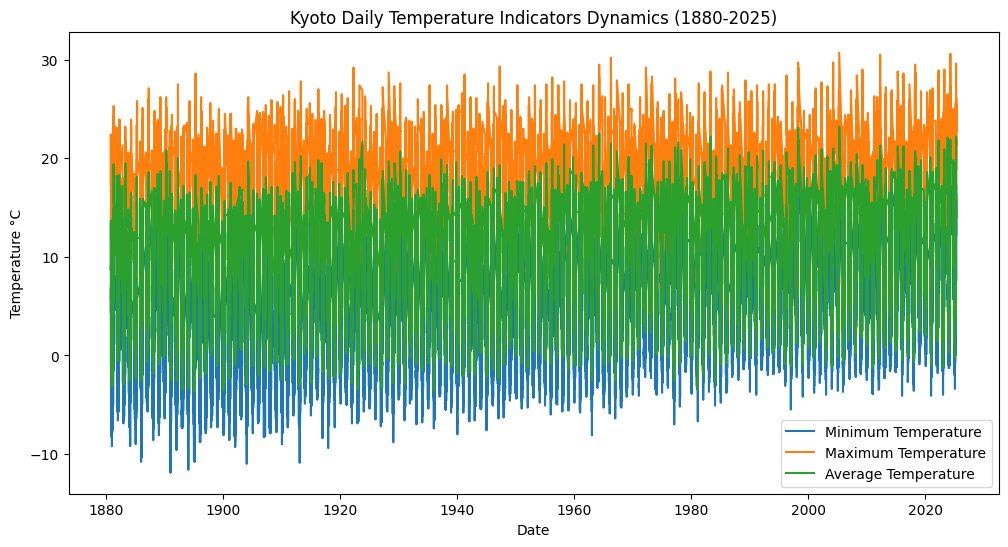

In [30]:
#analyze the temperature dynamics throughout the years
plt.figure(figsize=(12,6))
plt.plot(df_kyoto["date"], df_kyoto[["min temp", "max temp", "avg temp"]])
plt.xlabel("Date")
plt.ylabel("Temperature °C")
plt.title("Kyoto Daily Temperature Indicators Dynamics (1880-2025)")
plt.legend(["Minimum Temperature", "Maximum Temperature", "Average Temperature"], loc="lower right")
plt.show()

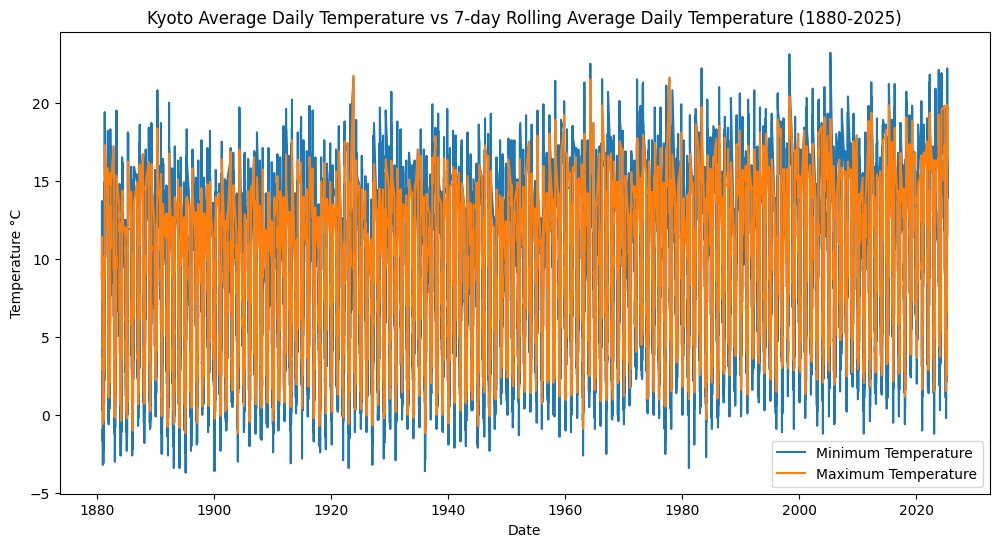

In [31]:
#daily average temperature and 7-day rolling averge temperature comparison
plt.figure(figsize=(12,6))
plt.plot(df_kyoto["date"], df_kyoto[["avg temp", "7-day rolling avg temp"]])
plt.xlabel("Date")
plt.ylabel("Temperature °C")
plt.title("Kyoto Average Daily Temperature vs 7-day Rolling Average Daily Temperature (1880-2025)")
plt.legend(["Minimum Temperature", "Maximum Temperature", "Average Temperature"], loc="lower right")
plt.show()

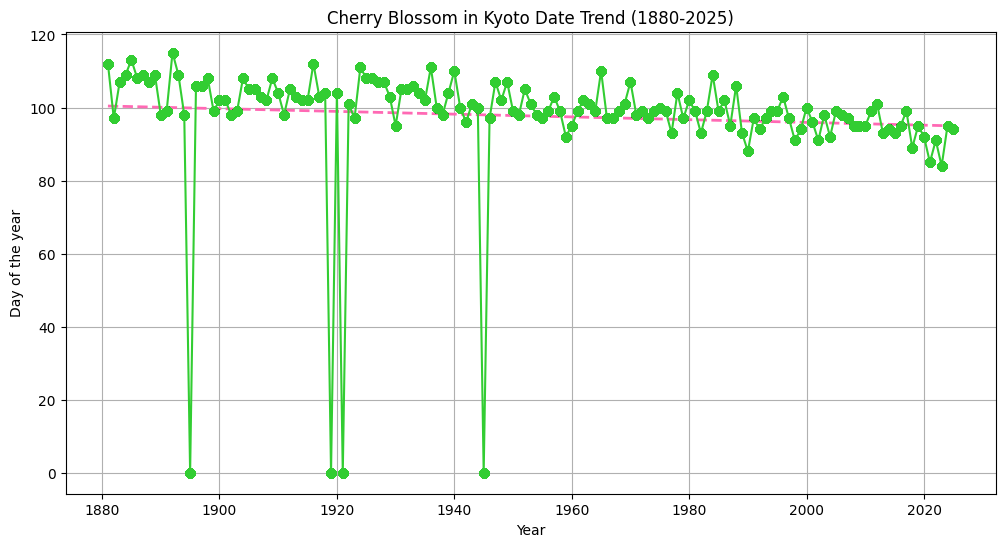

In [32]:
#plot the graph with a trend for peak bloom dates throughout the years
plt.figure(figsize=(12, 6))
z = np.polyfit(df_kyoto["season"], df_kyoto["bloom day of the year"], 1)
p = np.poly1d(z)
plt.plot(df_kyoto["season"].astype(int), p(df_kyoto["season"].astype(int)), color='hotpink', linestyle='--', linewidth=2, label='Trend Line')
plt.plot(df_kyoto["season"], df_kyoto["bloom day of the year"], marker="o", color="limegreen")
plt.title("Cherry Blossom in Kyoto Date Trend (1880-2025)")
plt.ylabel("Day of the year")
plt.xlabel("Year")
plt.grid(True)
plt.show()

In [33]:
df_kyoto_analysis = df_kyoto_weather.merge(
    df_kyoto_bloom[["date", "20-year avg day of the year with peak cherry blossom"]],
    on="date")

In [34]:
df_kyoto_analysis

,date,season,min temp,max temp,avg temp,cumulative avg temp,7-day rolling avg temp,daily gdd,cumulative gdd,chill,...,cumulative gdd after chill,clim avg,temp anomaly,cumulative temp anomaly,gdd diff,gdd acceleration,day in season,20-year avg day of the year with peak cherry blossom_x,bloom day of the year,20-year avg day of the year with peak cherry blossom_y
0,1881-04-22,1881,1.3,15.4,9.3,767.7,11.200000,4.3,247.6,0.0,...,0.0,14.426207,-5.126207,-460.598800,4.3,-3.1,172,105.30,112.0,105.30
1,1882-04-07,1882,-0.6,17.3,7.9,936.6,11.000000,2.9,318.2,0.0,...,0.0,11.336552,-3.436552,-103.601649,2.9,0.3,157,105.15,97.0,105.15
2,1883-04-17,1883,-1.9,17.3,8.2,845.5,9.400000,3.2,257.3,0.0,...,0.0,13.553793,-5.353793,-320.966476,3.2,1.6,167,104.65,107.0,104.65
3,1884-04-18,1884,6.2,20.1,13.2,845.1,14.342857,8.2,273.5,0.0,...,0.0,14.173103,-0.973103,-343.692370,8.2,-0.2,168,104.20,109.0,104.20
4,1885-04-23,1885,4.7,21.2,14.5,733.0,13.371429,9.5,239.6,0.0,...,0.0,14.535862,-0.035862,-509.834662,9.5,1.4,173,104.60,113.0,104.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136,2021-03-26,2021,6.7,19.6,11.9,1286.9,12.214286,6.9,610.2,0.0,...,0.0,8.230345,3.669655,379.621890,6.9,-1.1,145,94.75,85.0,94.75
137,2022-04-01,2022,5.2,12.6,8.8,1205.2,12.842857,3.8,519.4,0.0,...,0.0,10.454483,-1.654483,230.921800,3.8,-4.3,151,94.75,91.0,94.75
138,2023-03-25,2023,9.6,17.3,12.6,1258.9,14.328571,7.6,590.1,0.0,...,0.0,8.283448,4.316552,350.013524,7.6,-4.4,144,94.05,84.0,94.05
139,2024-04-04,2024,11.4,18.1,14.7,1384.3,15.828571,9.7,636.2,0.0,...,0.0,11.004828,3.695172,372.301424,9.7,0.7,154,94.20,95.0,94.20


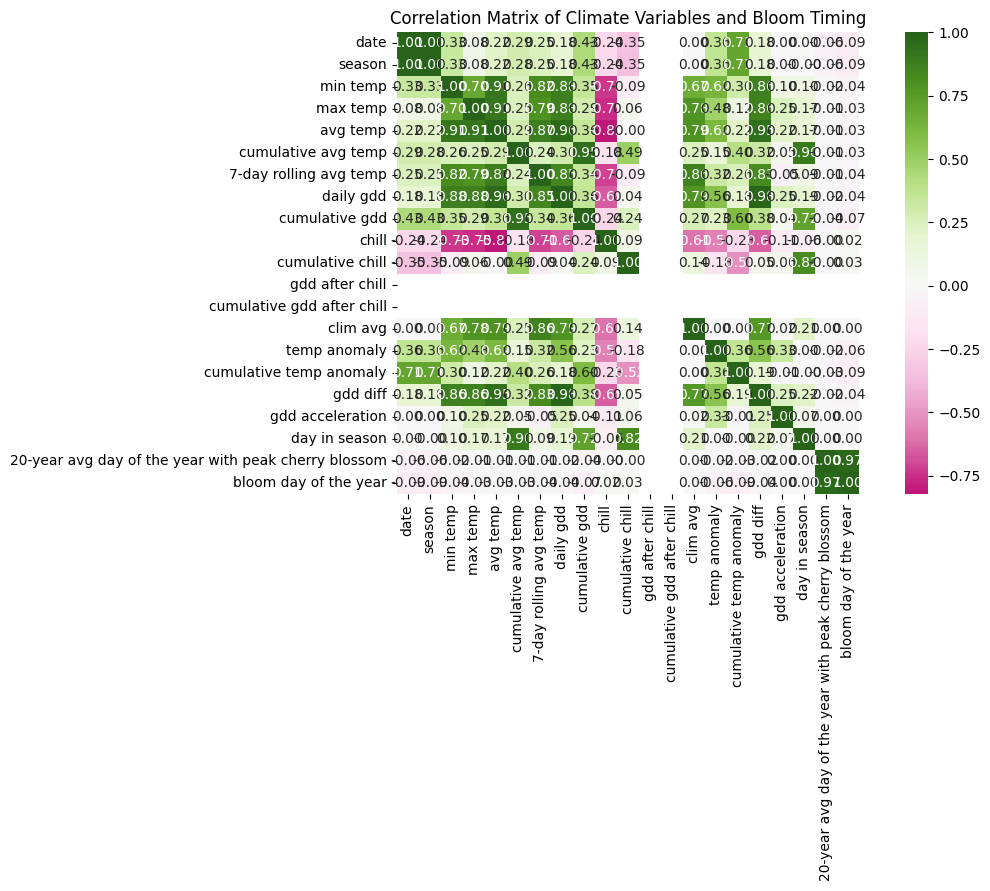

In [35]:
#get the correlation matrix
correlation_matrix = df_kyoto.corr()
plt.figure(figsize=(12, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="PiYG", center=0, square=True, fmt=".2f")
plt.title('Correlation Matrix of Climate Variables and Bloom Timing')
plt.show()

In [36]:
#define the target column
feature_cols = ["min temp", "max temp",	"avg temp", "cumulative avg temp", "7-day rolling avg temp",
                "daily gdd", "cumulative gdd", "chill",	"cumulative chill", "gdd after chill", "cumulative gdd after chill",
                "clim avg",	"temp anomaly",	"cumulative temp anomaly", "gdd diff", "gdd acceleration", "day in season",
                "20-year avg day of the year with peak cherry blossom"]

target_col = "bloom day of the year"

In [37]:
#separate features and the target
years = df_kyoto["season"].unique()

x_list= []
y_list = []

for year, group in df_kyoto.groupby("season"):
    group = group.sort_values("date")
    features = group[feature_cols].values.astype(np.float32)
    target = group[target_col].iloc[0]
    x_list.append(features)
    y_list.append(target)
x = np.array(x_list,  dtype=np.float32)
y = np.array(y_list,  dtype=np.float32)

In [38]:
x

array([[[  4.4 ,  17.2 ,   9.1 , ...,   0.  ,   0.  , 105.3 ],
        [  2.  ,  18.3 ,   8.6 , ...,   0.  ,   1.  , 105.3 ],
        [  4.4 ,  22.4 ,  12.9 , ...,   4.3 ,   2.  , 105.3 ],
        ...,
        [ 16.9 ,  21.7 ,  18.6 , ...,  -0.3 , 178.  , 105.3 ],
        [  8.6 ,  20.2 ,  14.  , ...,  -4.6 , 179.  , 105.3 ],
        [  6.9 ,  23.8 ,  15.5 , ...,   1.5 , 180.  , 105.3 ]],

       [[  5.2 ,  21.8 ,  13.6 , ...,   0.  ,   0.  , 105.15],
        [  4.5 ,  18.7 ,  10.1 , ...,   0.  ,   1.  , 105.15],
        [  5.4 ,  19.  ,  16.6 , ...,   6.5 ,   2.  , 105.15],
        ...,
        [ 12.9 ,  19.7 ,  17.1 , ...,   0.9 , 178.  , 105.15],
        [  9.4 ,  21.3 ,  15.4 , ...,  -1.7 , 179.  , 105.15],
        [  5.1 ,  18.2 ,  11.8 , ...,  -3.6 , 180.  , 105.15]],

       [[ 12.4 ,  21.3 ,  17.2 , ...,   0.  ,   0.  , 104.65],
        [  6.4 ,  17.2 ,  11.3 , ...,   0.  ,   1.  , 104.65],
        [  5.8 ,  17.6 ,  15.1 , ...,   3.8 ,   2.  , 104.65],
        ...,
        [ 15

In [39]:
y

array([112.,  97., 107., 109., 113., 108., 109., 107., 109.,  98.,  99.,
       115., 109.,  98.,   0., 106., 106., 108.,  99., 102., 102.,  98.,
        99., 108., 105., 105., 103., 102., 108., 104.,  98., 105., 103.,
       102., 102., 112., 103., 104.,   0., 104.,   0., 101.,  97., 111.,
       108., 108., 107., 107., 103.,  95., 105., 105., 106., 104., 102.,
       111., 100.,  98., 104., 110., 100.,  96., 101., 100.,   0.,  97.,
       107., 102., 107.,  99.,  98., 105., 101.,  98.,  97.,  99., 103.,
        99.,  92.,  95.,  99., 102., 101.,  99., 110.,  97.,  97.,  99.,
       101., 107.,  98.,  99.,  97.,  99., 100.,  99.,  93., 104.,  97.,
       102.,  99.,  93.,  99., 109.,  99., 102.,  95., 106.,  93.,  88.,
        97.,  94.,  97.,  99.,  99., 103.,  97.,  91.,  94., 100.,  96.,
        91.,  98.,  92.,  99.,  98.,  97.,  95.,  95.,  95.,  99., 101.,
        93.,  94.,  93.,  95.,  99.,  89.,  95.,  92.,  85.,  91.,  84.,
        95.,  94.], dtype=float32)

In [40]:
#check the shape
print(x.shape, y.shape, sep="\n")

(145, 181, 18)
(145,)


In [41]:
#make a split into train, validation, and test datasets.
years = df_kyoto["season"].unique()
years = np.array(years)
train_period = years <= 1993
val_period = (years > 1993) & (years < 2008)
test_period = years >= 2008

x_train, y_train = x[train_period], y[train_period]
x_val, y_val = x[val_period], y[val_period]
x_test, y_test = x[test_period], y[test_period]

In [42]:
x_test

array([[[ 13.5 ,  16.9 ,  15.4 , ...,   0.  ,   0.  ,  95.9 ],
        [ 10.8 ,  18.5 ,  14.6 , ...,   0.  ,   1.  ,  95.9 ],
        [  7.9 ,  19.9 ,  13.1 , ...,  -1.5 ,   2.  ,  95.9 ],
        ...,
        [ 11.3 ,  21.4 ,  15.5 , ...,  -0.6 , 178.  ,  95.9 ],
        [  9.5 ,  25.5 ,  17.8 , ...,   2.3 , 179.  ,  95.9 ],
        [ 13.2 ,  28.4 ,  20.4 , ...,   2.6 , 180.  ,  95.9 ]],

       [[ 11.1 ,  20.9 ,  15.2 , ...,   0.  ,   0.  ,  96.  ],
        [ 10.2 ,  19.9 ,  14.9 , ...,   0.  ,   1.  ,  96.  ],
        [ 13.3 ,  21.  ,  16.4 , ...,   1.5 ,   2.  ,  96.  ],
        ...,
        [  5.4 ,  17.5 ,  11.7 , ...,   1.4 , 178.  ,  96.  ],
        [  5.9 ,  22.8 ,  13.7 , ...,   2.  , 179.  ,  96.  ],
        [  6.9 ,  24.  ,  15.8 , ...,   2.1 , 180.  ,  96.  ]],

       [[ 14.7 ,  23.1 ,  17.9 , ...,   0.  ,   0.  ,  96.35],
        [  5.9 ,  18.3 ,  11.9 , ...,   0.  ,   1.  ,  96.35],
        [  5.2 ,  13.  ,   8.  , ...,  -3.9 ,   2.  ,  96.35],
        ...,
        [ 12

In [43]:
y_test

array([ 95.,  95.,  95.,  99., 101.,  93.,  94.,  93.,  95.,  99.,  89.,
        95.,  92.,  85.,  91.,  84.,  95.,  94.], dtype=float32)

In [44]:
#Standardize the data via sklearn StandardScaler
scaler = StandardScaler()
x_train_2d = x_train.reshape(-1, x_train.shape[-1])
x_val_2d   = x_val.reshape(-1, x_val.shape[-1])
x_test_2d = x_test.reshape(-1, x_test.shape[-1])

x_train = scaler.fit_transform(x_train_2d).reshape(x_train.shape)
x_val = scaler.transform(x_val_2d).reshape(x_val.shape)
x_test = scaler.transform(x_test_2d).reshape(x_test.shape)

y_train = scaler.fit_transform(y_train.reshape(-1,1)).flatten()
y_val = scaler.transform(y_val.reshape(-1,1)).flatten()
y_test = scaler.transform(y_test.reshape(-1,1)).flatten()

In [45]:
x_test

array([[[ 2.3757937 ,  0.7600453 ,  1.7814356 , ..., -0.00702647,
         -1.7225077 , -0.16558786],
        [ 1.8105521 ,  1.0674969 ,  1.6098684 , ..., -0.00702647,
         -1.7033688 , -0.16558786],
        [ 1.2034407 ,  1.3365169 ,  1.2881798 , ..., -0.8425641 ,
         -1.6842299 , -0.16558786],
        ...,
        [ 1.9152265 ,  1.6247526 ,  1.8028816 , ..., -0.34124157,
          1.6842299 , -0.16558786],
        [ 1.5383986 ,  2.4125972 ,  2.2961376 , ...,  1.2741313 ,
          1.7033688 , -0.16558786],
        [ 2.312989  ,  2.969853  ,  2.8537312 , ...,  1.4412388 ,
          1.7225077 , -0.16558786]],

       [[ 1.8733568 ,  1.528674  ,  1.7385439 , ..., -0.00702647,
         -1.7225077 , -0.16035762],
        [ 1.6849427 ,  1.3365169 ,  1.674206  , ..., -0.00702647,
         -1.7033688 , -0.16035762],
        [ 2.333924  ,  1.5478898 ,  1.9958948 , ...,  0.8285112 ,
         -1.6842299 , -0.16035762],
        ...,
        [ 0.68006873,  0.8753397 ,  0.98793685, ...,  

In [46]:
y_test

array([-0.17764701, -0.17764701, -0.17764701,  0.02719087,  0.12960981,
       -0.28006595, -0.22885647, -0.28006595, -0.17764701,  0.02719087,
       -0.4849038 , -0.17764701, -0.3312754 , -0.6897417 , -0.38248488,
       -0.7409511 , -0.17764701, -0.22885647], dtype=float32)

In [47]:
#Build an LSTM model
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_layers, dropout):
        super(LSTMModel, self).__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = n_layers
        self.dropout = dropout
        
        self.lstm = nn.LSTM(input_dim, hidden_dim, n_layers, batch_first=True, dropout=dropout)
        
        self.fc = nn.Linear(hidden_dim, 1)
        
    def forward(self, x):
        output, _ = self.lstm(x)
        output = output[:, -1, :]
        output = self.fc(output)
        
        return output.squeeze()

In [48]:
#create the checkpoints directory
checkpoint_dir = "data/kyoto_lstm_checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

In [49]:
#save checkpoint function: epoch - the epoch that will be saved, model - the training model, optimizer - the optimizer used in training,
#loss - value for the epoch's train loss function, path - the directory where the saved checkpoint will be stored)
def save_checkpoint(epoch, model, optimizer, loss, path):
    print("=>Saving the model checkpoint")
    checkpoint = {"epoch" : epoch,
                  "model_state" : model.state_dict(),
                  "optimizer_state" : optimizer.state_dict(),
                 "loss" : loss}
    torch.save(checkpoint, path)
    print(f"Saved the model checkpoint at epoch {checkpoint["epoch"]} ✓")

In [50]:
# load checkpoint function: path - , model - , optimizer -, device - )
def load_checkpoint(path, model, optimizer=None, device="cpu"):
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    if optimizer is not None and "optimizer_state" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer_state"])
    print(f"Loaded the model checkpoint at epoch {checkpoint["epoch"]} ✓")
    return checkpoint["epoch"]

In [51]:
#training parameters
epochs = 1000
save_epoch = 10
train_losses = []
val_losses = []
hidden_dim = 32
n_layers = 1
dropout=0
lr = 0.0001
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [52]:
#create the tensors for the model training.
x_train_tensor = torch.tensor(x_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)

x_val_tensor = torch.tensor(x_val, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).to(device)

x_test_tensor = torch.tensor(x_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

In [53]:
#check the tensors shapes
print(x_train_tensor.shape)
print(y_train_tensor.shape)

torch.Size([113, 181, 18])
torch.Size([113])


In [54]:
#define the model
model = LSTMModel(x.shape[2], hidden_dim, n_layers, dropout)

In [55]:
#set the model to cuda, define the criterion and the optimizer
model.to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

In [56]:
#the training loop
for epoch in range(1, epochs+1):
    model.train()
    optimizer.zero_grad()
    preds = model(x_train_tensor)
    train_loss = criterion(preds, y_train_tensor)
    train_loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_preds = model(x_val_tensor)
        val_loss = criterion(val_preds, y_val_tensor)
        
    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

    if epoch % 10 == 0:
        save_path = os.path.join(checkpoint_dir,f"epoch_{epoch}.pth")
        save_checkpoint(epoch, model, optimizer, train_loss.item(), save_path)
        print(f"Epoch {epoch} | "
              f"Train Loss: {train_loss.item():.2f} | "
              f"Validation Loss: {val_loss.item():.2f}"
             )

=>Saving the model checkpoint
Saved the model checkpoint at epoch 10 ✓
Epoch 10 | Train Loss: 1.00 | Validation Loss: 0.03
=>Saving the model checkpoint
Saved the model checkpoint at epoch 20 ✓
Epoch 20 | Train Loss: 0.98 | Validation Loss: 0.03
=>Saving the model checkpoint
Saved the model checkpoint at epoch 30 ✓
Epoch 30 | Train Loss: 0.97 | Validation Loss: 0.03
=>Saving the model checkpoint
Saved the model checkpoint at epoch 40 ✓
Epoch 40 | Train Loss: 0.95 | Validation Loss: 0.03
=>Saving the model checkpoint
Saved the model checkpoint at epoch 50 ✓
Epoch 50 | Train Loss: 0.93 | Validation Loss: 0.02
=>Saving the model checkpoint
Saved the model checkpoint at epoch 60 ✓
Epoch 60 | Train Loss: 0.91 | Validation Loss: 0.02
=>Saving the model checkpoint
Saved the model checkpoint at epoch 70 ✓
Epoch 70 | Train Loss: 0.89 | Validation Loss: 0.02
=>Saving the model checkpoint
Saved the model checkpoint at epoch 80 ✓
Epoch 80 | Train Loss: 0.87 | Validation Loss: 0.02
=>Saving the mod

In [57]:
#print the last epoch's metric
print("Final train MSE:", train_losses[-1])
print("Final train RMSE:", train_losses[-1] ** 0.5)

print("Final val MSE:", val_losses[-1])
print("Final val RMSE:", val_losses[-1] ** 0.5)

Final train MSE: 0.007652414962649345
Final train RMSE: 0.08747808275590718
Final val MSE: 0.031844258308410645
Final val RMSE: 0.17844959598836485


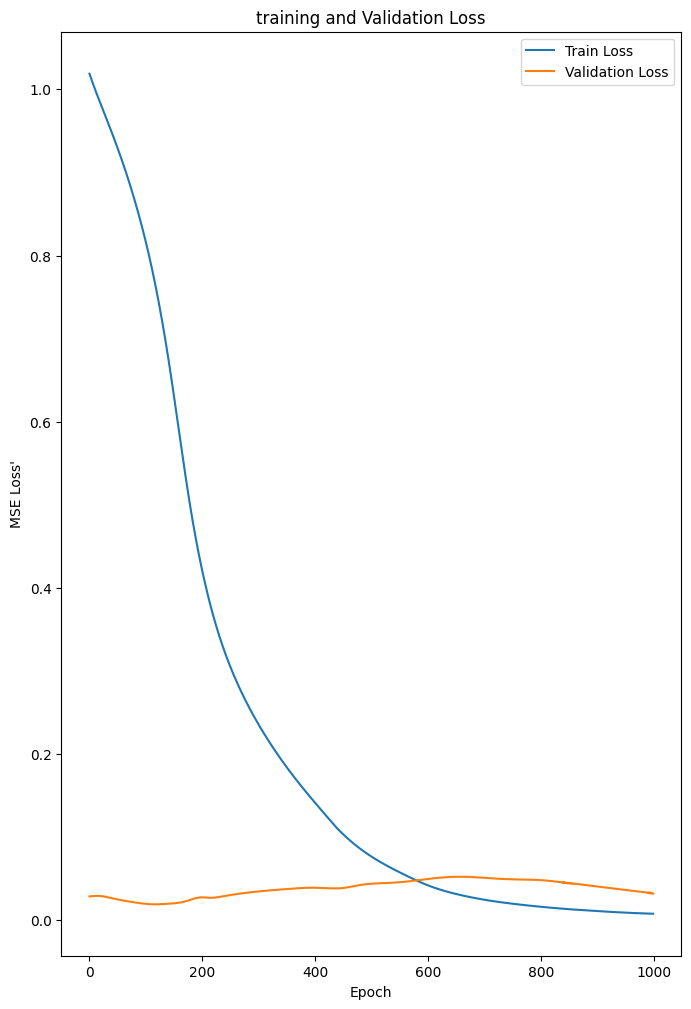

In [58]:
#the training process graph
plt.figure(figsize=(8,12))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss'")
plt.title("training and Validation Loss")
plt.legend()
plt.show()

In [59]:
#load the checkpoint with the minimal loss
loaded_checkpoint = load_checkpoint("data/kyoto_lstm_checkpoints/epoch_180.pth", model)

Loaded the model checkpoint at epoch 180 ✓


In [60]:
loaded_checkpoint

180

In [61]:
#make the predictions
model = model.cpu()
model.eval()
with torch.no_grad():
    predictions_test = model(x_test_tensor.cpu()).numpy()

In [62]:
#unscale the predictions
predictions_test = scaler.inverse_transform(predictions_test.reshape(-1,1))

In [63]:
predictions_test.shape

(18, 1)

In [102]:
#build a comparative table
predicted_doy = pd.DataFrame(predictions_test, columns=["bloom day of the year"])
predicted_doy["year"] = pd.Series([2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])
predicted_doy["predicted bloom day of the year"] = predicted_doy["bloom day of the year"].round().astype(int)
predicted_doy["predicted date"] = pd.to_datetime(predicted_doy["year"].astype(str) + "-" + predicted_doy["predicted bloom day of the year"].astype(str), format='%Y-%j')
actual = df_kyoto_bloom.loc[df_kyoto_bloom["season"].between(2008, 2026),["season", "bloom day of the year"]]
actual = actual.rename(columns={"season" : "year", "bloom day of the year" : "actual bloom day of the year"})
predicted_doy = predicted_doy.merge(actual, on="year", how="left")
predicted_doy["actual date"] = pd.to_datetime(predicted_doy["year"].astype(str) + "-" + predicted_doy["actual bloom day of the year"].astype(str), format='%Y-%j')
predicted_doy["error in days"] = (predicted_doy["predicted bloom day of the year"] - predicted_doy["actual bloom day of the year"])
predicted_doy = predicted_doy[["year", "predicted bloom day of the year", "actual bloom day of the year", "actual date", "predicted date", "error in days"]]

In [103]:
predicted_doy

,year,predicted bloom day of the year,actual bloom day of the year,actual date,predicted date,error in days
0,2008,94,95,2008-04-04,2008-04-03,-1
1,2009,96,95,2009-04-05,2009-04-06,1
2,2010,97,95,2010-04-05,2010-04-07,2
3,2011,97,99,2011-04-09,2011-04-07,-2
4,2012,95,101,2012-04-10,2012-04-04,-6
5,2013,97,93,2013-04-03,2013-04-07,4
6,2014,95,94,2014-04-04,2014-04-05,1
7,2015,93,93,2015-04-03,2015-04-03,0
8,2016,95,95,2016-04-04,2016-04-04,0
9,2017,94,99,2017-04-09,2017-04-04,-5


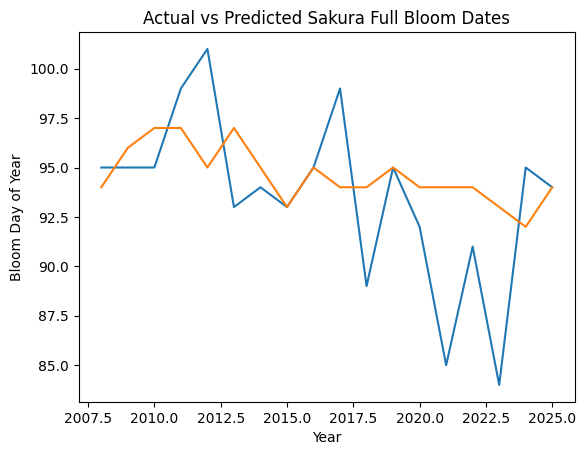

In [66]:
#built a comparative graph for the actual and predicted bloom dates
plt.figure()
plt.plot(predicted_doy["year"], predicted_doy["actual bloom day of the year"])
plt.plot(predicted_doy["year"], predicted_doy["predicted bloom day of the year"])
plt.xlabel("Year")
plt.ylabel("Bloom Day of Year")
plt.title("Actual vs Predicted Sakura Full Bloom Dates")
plt.show()

In [67]:
#build the train, test, and validation tensors for an MLP training
batch_size, seq_len, n_features = x_train_tensor.shape

x_train_tensor_mlp = x_train_tensor.view(-1, n_features)
x_val_tensor_mlp = x_val_tensor.view(-1, n_features)
x_test_tensor_mlp = x_test_tensor.view(-1, n_features)

In [68]:
#build the train, test, and validation tensors for an MLP training
y_train_tensor_mlp = y_train_tensor.repeat_interleave(seq_len, dim=0).view(-1, 1)
y_val_tensor_mlp = y_val_tensor.repeat_interleave(seq_len, dim=0).view(-1, 1)
y_test_tensor_mlp = y_test_tensor.repeat_interleave(seq_len, dim=0).view(-1, 1)

In [69]:
#define the input dimensions
input_dim = n_features

In [70]:
#build the MLP model
class BloomMLP(nn.Module):
    def __init__(self, input_dim):
        super(BloomMLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )
        
    def forward(self, x):
        return self.layers(x)

In [71]:
#define the MLP model
mlp = BloomMLP(input_dim).to(device)

In [72]:
##create the MLP checkpoints directory
checkpoint_dir_mlp = "data/kyoto_mlp_checkpoints"
os.makedirs(checkpoint_dir_mlp, exist_ok=True)

In [73]:
#MLP training parameters
epochs_mlp = 1000
save_epoch_mlp = 10
train_losses_mlp = []
val_losses_mlp = []
lr_mlp = 0.001

In [74]:
#define the criterion and the optimizer
criterion_mlp = nn.MSELoss()
optimizer_mlp = torch.optim.Adam(mlp.parameters(), lr=lr_mlp)

In [75]:
#train the MLP model
for epoch in range(1, epochs_mlp + 1):
    mlp.train()
    preds = mlp(x_train_tensor_mlp)
    train_loss = criterion_mlp(preds, y_train_tensor_mlp)
    optimizer_mlp.zero_grad()
    train_loss.backward()
    optimizer_mlp.step()
    
    mlp.eval()
    with torch.no_grad():
        val_preds = mlp(x_val_tensor_mlp)
        val_loss = criterion_mlp(val_preds, y_val_tensor_mlp)
        
    train_losses_mlp.append(train_loss.item())
    val_losses_mlp.append(val_loss.item())

    if epoch % 10 == 0:
        save_path_mlp = os.path.join(checkpoint_dir_mlp,f"epoch_{epoch}.pth")
        save_checkpoint(epoch, mlp, optimizer_mlp, train_loss.item(), save_path_mlp)
        print(f"Epoch {epoch} | "
              f"Train Loss: {train_loss.item():.2f} | "
              f"Validation Loss: {val_loss.item():.2f}"
             )

=>Saving the model checkpoint
Saved the model checkpoint at epoch 10 ✓
Epoch 10 | Train Loss: 0.96 | Validation Loss: 0.06
=>Saving the model checkpoint
Saved the model checkpoint at epoch 20 ✓
Epoch 20 | Train Loss: 0.90 | Validation Loss: 0.04
=>Saving the model checkpoint
Saved the model checkpoint at epoch 30 ✓
Epoch 30 | Train Loss: 0.81 | Validation Loss: 0.04
=>Saving the model checkpoint
Saved the model checkpoint at epoch 40 ✓
Epoch 40 | Train Loss: 0.68 | Validation Loss: 0.03
=>Saving the model checkpoint
Saved the model checkpoint at epoch 50 ✓
Epoch 50 | Train Loss: 0.53 | Validation Loss: 0.04
=>Saving the model checkpoint
Saved the model checkpoint at epoch 60 ✓
Epoch 60 | Train Loss: 0.36 | Validation Loss: 0.03
=>Saving the model checkpoint
Saved the model checkpoint at epoch 70 ✓
Epoch 70 | Train Loss: 0.20 | Validation Loss: 0.03
=>Saving the model checkpoint
Saved the model checkpoint at epoch 80 ✓
Epoch 80 | Train Loss: 0.10 | Validation Loss: 0.03
=>Saving the mod

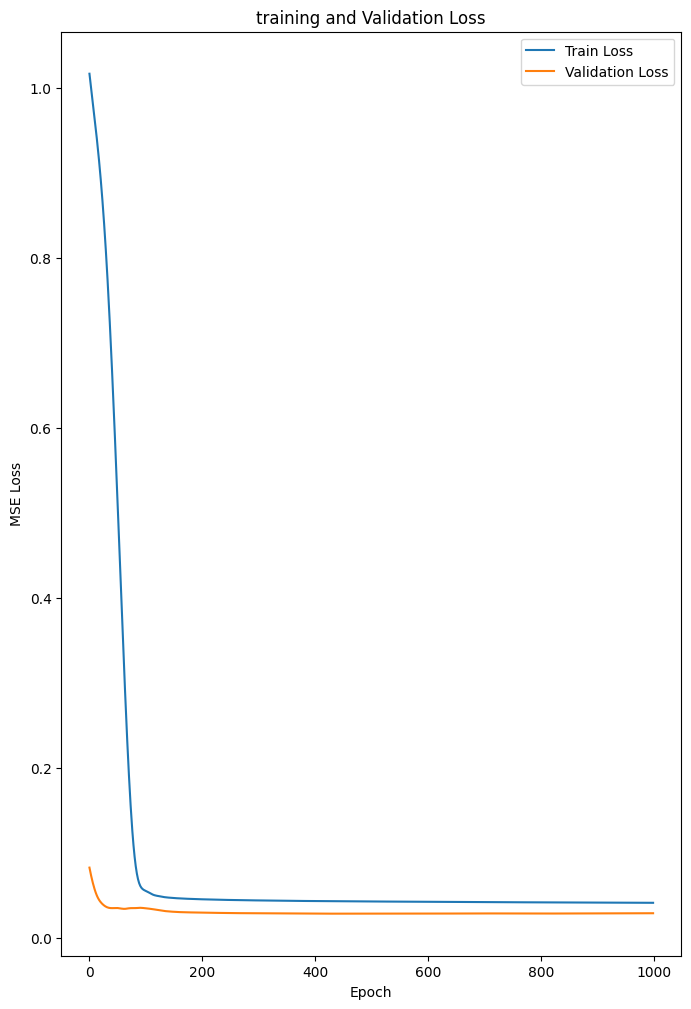

In [76]:
#build the training graph
plt.figure(figsize=(8,12))
plt.plot(train_losses_mlp, label="Train Loss")
plt.plot(val_losses_mlp, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("training and Validation Loss")
plt.legend()
plt.show()

In [77]:
# load the checkpoint with the lowest validation loss
checkpoint_path_mlp = "data/kyoto_mlp_checkpoints/epoch_900.pth"  # Adjust epoch number as needed
loaded_checkpoint_mlp = load_checkpoint(checkpoint_path_mlp, mlp)

# move model to CPU for inference
mlp = mlp.cpu()
mlp.eval()

# make predictions on test set
with torch.no_grad():
    predictions_test_mlp = mlp(x_test_tensor_mlp.cpu()).numpy()
    
predictions_test_mlp = scaler.inverse_transform(predictions_test_mlp.reshape(-1, 1))

Loaded the model checkpoint at epoch 900 ✓


In [100]:
#build another comparison table for MLP
predicted_doy_mlp = pd.DataFrame()
predicted_doy_mlp["year"] = [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

predicted_doy_mlp["predicted bloom day of the year"] = predictions_test.flatten()

predicted_doy_mlp["predicted bloom day of the year"] = predicted_doy_mlp["predicted bloom day of the year"].round().astype(int)

predicted_doy_mlp["year"] = predicted_doy_mlp["year"].astype(int)

predicted_doy_mlp["doy_padded"] = predicted_doy_mlp["predicted bloom day of the year"].apply(lambda x: f"{x:03d}")
predicted_doy_mlp["date_str"] = predicted_doy_mlp["year"].astype(str) + "-" + predicted_doy_mlp["doy_padded"]
predicted_doy_mlp["predicted date"] = pd.to_datetime(predicted_doy_mlp["date_str"], format='%Y-%j')
actual_mlp = df_kyoto_bloom.loc[df_kyoto_bloom["season"].between(2008, 2026),["season", "bloom day of the year"]]
actual_mlp = actual_mlp.rename(columns={"season" : "year", "bloom day of the year" : "actual bloom day of the year"})
predicted_doy_mlp = predicted_doy_mlp.merge(actual_mlp, on="year", how="left")
predicted_doy_mlp["actual date"] = pd.to_datetime(predicted_doy_mlp["year"].astype(str) + "-" + predicted_doy_mlp["actual bloom day of the year"].astype(str), format='%Y-%j')
predicted_doy_mlp["error in days"] = (predicted_doy_mlp["predicted bloom day of the year"] - predicted_doy_mlp["actual bloom day of the year"])

In [101]:
predicted_doy_mlp = predicted_doy_mlp[["year", "predicted bloom day of the year", "actual bloom day of the year", "actual date", "predicted date", "error in days"]]
predicted_doy_mlp

,year,predicted bloom day of the year,actual bloom day of the year,actual date,predicted date,error in days
0,2008,94,95,2008-04-04,2008-04-03,-1
1,2009,96,95,2009-04-05,2009-04-06,1
2,2010,97,95,2010-04-05,2010-04-07,2
3,2011,97,99,2011-04-09,2011-04-07,-2
4,2012,95,101,2012-04-10,2012-04-04,-6
5,2013,97,93,2013-04-03,2013-04-07,4
6,2014,95,94,2014-04-04,2014-04-05,1
7,2015,93,93,2015-04-03,2015-04-03,0
8,2016,95,95,2016-04-04,2016-04-04,0
9,2017,94,99,2017-04-09,2017-04-04,-5


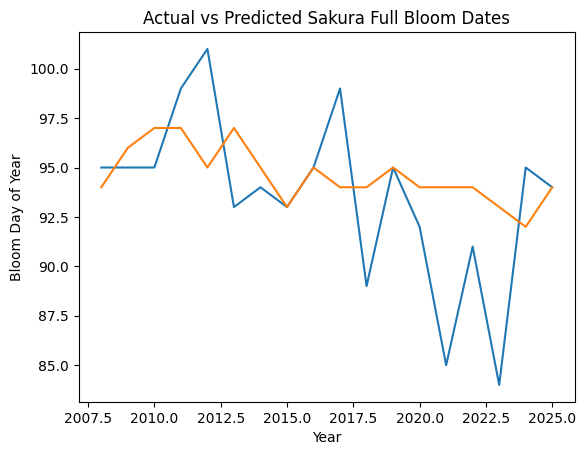

In [80]:
#build a comparative graph for the actual and predicted bloom dates
plt.figure()
plt.plot(predicted_doy["year"], predicted_doy["actual bloom day of the year"])
plt.plot(predicted_doy["year"], predicted_doy["predicted bloom day of the year"])
plt.xlabel("Year")
plt.ylabel("Bloom Day of Year")
plt.title("Actual vs Predicted Sakura Full Bloom Dates")
plt.show()

In [81]:
#import necessary libraries for XGBoost training
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

#XGBoost model
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [82]:
#create the tensors
df_kyoto_xgb = df_kyoto.drop_duplicates(subset=['season'], keep='last')

X_train = df_kyoto_xgb.loc[df_kyoto_xgb['season'].between(1880, 1993)]
    
X_train = X_train[['min temp', 'max temp', 'avg temp',
       'cumulative avg temp', '7-day rolling avg temp', 'daily gdd',
       'cumulative gdd', 'chill', 'cumulative chill', 'gdd after chill',
       'cumulative gdd after chill', 'clim avg', 'temp anomaly',
       'cumulative temp anomaly', 'gdd diff', 'gdd acceleration',
       'day in season', '20-year avg day of the year with peak cherry blossom',]]

y_train = df_kyoto_xgb.loc[df_kyoto_xgb['season'].between(1880, 1993)]
y_train = y_train[['bloom day of the year']]


X_val = df_kyoto_xgb.loc[df_kyoto_xgb['season'].between(1994, 2007)]
    
X_val = X_val[['min temp', 'max temp', 'avg temp',
       'cumulative avg temp', '7-day rolling avg temp', 'daily gdd',
       'cumulative gdd', 'chill', 'cumulative chill', 'gdd after chill',
       'cumulative gdd after chill', 'clim avg', 'temp anomaly',
       'cumulative temp anomaly', 'gdd diff', 'gdd acceleration',
       'day in season', '20-year avg day of the year with peak cherry blossom',]]

y_val = df_kyoto_xgb.loc[df_kyoto_xgb['season'].between(1994, 2007)]
y_val = y_val[['bloom day of the year']]


X_test = df_kyoto_xgb.loc[df_kyoto_xgb['season'].between(2008, 2025)]
    
X_test = X_test[['min temp', 'max temp', 'avg temp',
       'cumulative avg temp', '7-day rolling avg temp', 'daily gdd',
       'cumulative gdd', 'chill', 'cumulative chill', 'gdd after chill',
       'cumulative gdd after chill', 'clim avg', 'temp anomaly',
       'cumulative temp anomaly', 'gdd diff', 'gdd acceleration',
       'day in season', '20-year avg day of the year with peak cherry blossom',]]

y_test = df_kyoto_xgb.loc[df_kyoto_xgb['season'].between(2008, 2025)]
y_test = y_test[['bloom day of the year']]

In [87]:
#train the model
xgb_model.fit(X_train, y_train)

#predict
y_pred_xgb_train = xgb_model.predict(X_train)
y_pred_xgb_val = xgb_model.predict(X_val)
y_pred_xgb_test = xgb_model.predict(X_test)

train_mse_xgb = mean_squared_error(y_train, y_pred_xgb_train)
train_rmse_xgb = np.sqrt(mean_squared_error(y_train, y_pred_xgb_train))
val_mse_xgb = mean_squared_error(y_val, y_pred_xgb_val)
val_rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb_val))
test_mse_xgb = mean_squared_error(y_test, y_pred_xgb_test)
test_rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb_test))

print(f"Ridge Train MSE: {train_mse_xgb:.2f} days")
print(f"Ridge Train RMSE: {train_rmse_xgb:.2f} days")
print(f"Ridge Val MSE: {val_mse_xgb:.2f} days")
print(f"Ridge Val RMSE: {val_rmse_xgb:.2f} days")
print(f"Ridge Test MSE: {test_mse_xgb:.2f} days")
print(f"Ridge Train RMSE: {test_rmse_xgb:.2f} days")

Ridge Train MSE: 0.02 days
Ridge Train RMSE: 0.14 days
Ridge Val MSE: 4732.02 days
Ridge Val RMSE: 68.79 days
Ridge Test MSE: 5723.60 days
Ridge Train RMSE: 75.65 days


In [99]:
#create a comparative table
predicted_doy_xgb = pd.DataFrame()
predicted_doy_xgb["year"] = [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

predicted_doy_xgb["predicted bloom day of the year"] = y_pred_xgb_test.flatten()

predicted_doy_xgb["predicted bloom day of the year"] = predicted_doy_xgb["predicted bloom day of the year"].round().astype(int)

predicted_doy_xgb["year"] = predicted_doy_xgb["year"].astype(int)

predicted_doy_xgb["doy_padded"] = predicted_doy_xgb["predicted bloom day of the year"].apply(lambda x: f"{x:03d}")
predicted_doy_xgb["date_str"] = predicted_doy_xgb["year"].astype(str) + "-" + predicted_doy_xgb["doy_padded"]
predicted_doy_xgb["predicted date"] = pd.to_datetime(predicted_doy_xgb["date_str"], format='%Y-%j')
actual_xgb = df_kyoto_bloom.loc[df_kyoto_bloom["season"].between(2008, 2026),["season", "bloom day of the year"]]
actual_xgb = actual_xgb.rename(columns={"season" : "year", "bloom day of the year" : "actual bloom day of the year"})
predicted_doy_xgb = predicted_doy_xgb.merge(actual_xgb, on="year", how="left")
predicted_doy_xgb["actual date"] = pd.to_datetime(predicted_doy_xgb["year"].astype(str) + "-" + predicted_doy_xgb["actual bloom day of the year"].astype(str), format='%Y-%j')
predicted_doy_xgb["error in days"] = (predicted_doy_xgb["predicted bloom day of the year"] - predicted_doy_xgb["actual bloom day of the year"])

predicted_doy_xgb = predicted_doy_xgb[["year", "predicted bloom day of the year", "actual bloom day of the year", "actual date", "predicted date", "error in days"]]
predicted_doy_xgb

,year,predicted bloom day of the year,actual bloom day of the year,actual date,predicted date,error in days
0,2008,19,95,2008-04-04,2008-01-19,-76
1,2009,20,95,2009-04-05,2009-01-20,-75
2,2010,21,95,2010-04-05,2010-01-21,-74
3,2011,22,99,2011-04-09,2011-01-22,-77
4,2012,19,101,2012-04-10,2012-01-19,-82
5,2013,18,93,2013-04-03,2013-01-18,-75
6,2014,15,94,2014-04-04,2014-01-15,-79
7,2015,14,93,2015-04-03,2015-01-14,-79
8,2016,18,95,2016-04-04,2016-01-18,-77
9,2017,18,99,2017-04-09,2017-01-18,-81


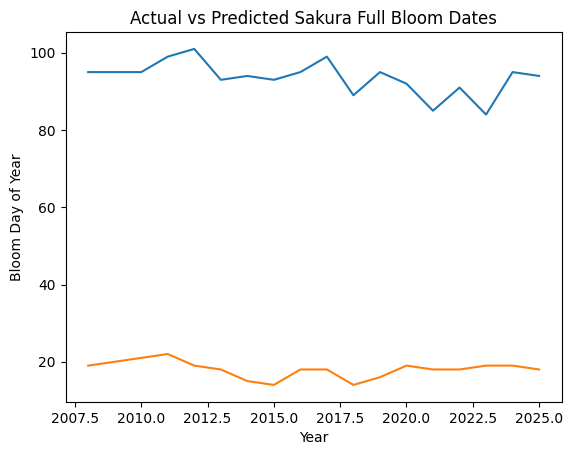

In [89]:
#build a comparative graph
plt.figure()
plt.plot(predicted_doy_xgb["year"], predicted_doy_xgb["actual bloom day of the year"])
plt.plot(predicted_doy_xgb["year"], predicted_doy_xgb["predicted bloom day of the year"])
plt.xlabel("Year")
plt.ylabel("Bloom Day of Year")
plt.title("Actual vs Predicted Sakura Full Bloom Dates")
plt.show()

In [90]:
# for more traditional machine learning approacg Ridge Regression was selected.
#train the Ridge Regression model.
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

y_pred_ridge_train = ridge_model.predict(X_train)
y_pred_ridge_val = ridge_model.predict(X_val)
y_pred_ridge_test = ridge_model.predict(X_test)

train_mse_ridge = mean_squared_error(y_train, y_pred_ridge_train)
train_rmse_ridge = np.sqrt(mean_squared_error(y_train, y_pred_ridge_train))
val_mse_ridge = mean_squared_error(y_val, y_pred_ridge_val)
val_rmse_ridge = np.sqrt(mean_squared_error(y_val, y_pred_ridge_val))
test_mse_ridge = mean_squared_error(y_test, y_pred_ridge_test)
test_rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge_test))

print(f"Ridge Train MSE: {train_mse_ridge:.2f} days")
print(f"Ridge Train RMSE: {train_rmse_ridge:.2f} days")
print(f"Ridge Val MSE: {val_mse_ridge:.2f} days")
print(f"Ridge Val RMSE: {val_rmse_ridge:.2f} days")
print(f"Ridge Test MSE: {test_mse_ridge:.2f} days")
print(f"Ridge Train RMSE: {test_rmse_ridge:.2f} days")

Ridge Train MSE: 11.90 days
Ridge Train RMSE: 3.45 days
Ridge Val MSE: 12.62 days
Ridge Val RMSE: 3.55 days
Ridge Test MSE: 14.12 days
Ridge Train RMSE: 3.76 days


In [97]:
#create the comparison dataframe for Ridge regression
predicted_doy_ridge = pd.DataFrame()
predicted_doy_ridge["year"] = [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

predicted_doy_ridge["predicted bloom day of the year"] = y_pred_ridge_test.flatten()

predicted_doy_ridge["predicted bloom day of the year"] = predicted_doy_ridge["predicted bloom day of the year"].round().astype(int)

predicted_doy_ridge["year"] = predicted_doy_ridge["year"].astype(int)

predicted_doy_ridge["doy_padded"] = predicted_doy_ridge["predicted bloom day of the year"].apply(lambda x: f"{x:03d}")
predicted_doy_ridge["date_str"] = predicted_doy_ridge["year"].astype(str) + "-" + predicted_doy_ridge["doy_padded"]
predicted_doy_ridge["predicted date"] = pd.to_datetime(predicted_doy_ridge["date_str"], format='%Y-%j')
actual_ridge = df_kyoto_bloom.loc[df_kyoto_bloom["season"].between(2008, 2026),["season", "bloom day of the year"]]
actual_ridge = actual_ridge.rename(columns={"season" : "year", "bloom day of the year" : "actual bloom day of the year"})
predicted_doy_ridge = predicted_doy_ridge.merge(actual_xgb, on="year", how="left")
predicted_doy_ridge["actual date"] = pd.to_datetime(predicted_doy_ridge["year"].astype(str) + "-" + predicted_doy_ridge["actual bloom day of the year"].astype(str), format='%Y-%j')
predicted_doy_ridge["error in days"] = (predicted_doy_ridge["predicted bloom day of the year"] - predicted_doy_ridge["actual bloom day of the year"])

predicted_doy_ridge = predicted_doy_ridge[["year", "predicted bloom day of the year", "actual bloom day of the year", "actual date", "predicted date", "error in days"]]

In [98]:
predicted_doy_ridge

,year,predicted bloom day of the year,actual bloom day of the year,actual date,predicted date,error in days
0,2008,95,95,2008-04-04,2008-04-04,0
1,2009,92,95,2009-04-05,2009-04-02,-3
2,2010,91,95,2010-04-05,2010-04-01,-4
3,2011,93,99,2011-04-09,2011-04-03,-6
4,2012,99,101,2012-04-10,2012-04-08,-2
5,2013,97,93,2013-04-03,2013-04-07,4
6,2014,94,94,2014-04-04,2014-04-04,0
7,2015,93,93,2015-04-03,2015-04-03,0
8,2016,92,95,2016-04-04,2016-04-01,-3
9,2017,92,99,2017-04-09,2017-04-02,-7


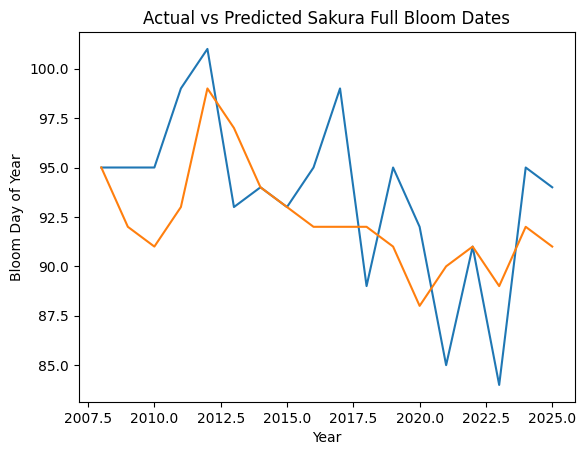

In [104]:
#
plt.figure()
plt.plot(predicted_doy_ridge["year"], predicted_doy_ridge["actual bloom day of the year"])
plt.plot(predicted_doy_ridge["year"], predicted_doy_ridge["predicted bloom day of the year"])
plt.xlabel("Year")
plt.ylabel("Bloom Day of Year")
plt.title("Actual vs Predicted Sakura Full Bloom Dates")
plt.show()

In [105]:
#make predictions
with torch.no_grad():
    predictions_val = model(x_val_tensor.cpu()).numpy()
    
predictions_val = scaler.inverse_transform(predictions_val.reshape(-1, 1)).flatten()
real_val = scaler.inverse_transform(y_val_tensor.cpu().reshape(-1,1)).flatten()

In [106]:
#unscale predictions
with torch.no_grad():
    predictions_val_mlp = mlp(x_val_tensor_mlp.cpu()).numpy()
    
predictions_val_mlp = scaler.inverse_transform(predictions_val_mlp.reshape(-1, 1)).flatten()
real_val_mlp = scaler.inverse_transform(y_val_tensor_mlp.cpu().reshape(-1,1)).flatten()

In [107]:
predictions_val

array([ 94.304634,  95.205864, 101.007904,  95.046074,  92.34191 ,
        96.18784 ,  96.95856 ,  94.92865 ,  94.187225,  97.06076 ,
        94.88121 ,  92.91421 ,  99.06836 ,  93.54545 ], dtype=float32)

In [109]:
#get unscaled LSTM evaluation metrics
mse_lstm = mean_squared_error(real_val, predictions_val)
mae_lstm = mean_absolute_error(real_val, predictions_val)
rmse_lstm = np.sqrt(mse_lstm)
mse_mlp = mean_squared_error(real_val_mlp, predictions_val_mlp)
mae_mlp = mean_absolute_error(real_val_mlp, predictions_val_mlp)
rmse_mlp = np.sqrt(mse_mlp)
mse_xgb = val_mse_xgb
mae_xgb = mean_absolute_error(y_val, y_pred_xgb_val)
rmse_xgb = val_rmse_xgb
mse_ridge = val_mse_ridge
mae_ridge = mean_absolute_error(y_val, y_pred_ridge_val)
rmse_ridge = val_rmse_ridge
print(mse_mlp, rmse_mlp)

10.955919088879241 3.309972671923326


In [110]:
#create a new dataframe to compare the models' metrics
comparison = pd.DataFrame({
    "Model": ["LSTM", "MLP", "XGB", "Ridge Regression"],
    "MSE": [mse_lstm, mse_mlp, mse_xgb, mse_ridge],
    "MAE" : [mae_lstm, mae_mlp, mae_xgb, mae_ridge],
    "RMSE": [rmse_lstm, rmse_mlp, rmse_xgb, rmse_ridge]
})

comparison = comparison.sort_values("RMSE")

In [111]:
comparison

,Model,MSE,MAE,RMSE
0,LSTM,9.333421,2.692461,3.055065
1,MLP,10.955919,2.840601,3.309973
3,Ridge Regression,12.618579,3.123627,3.552264
2,XGB,4732.020996,61.617760,68.789687
